## load iEEG timeseries and calculate band powers

In [1]:
ieegdir = '/home/yzhou/projects/MNI_iEEG/'

from scipy.io import loadmat
mat = loadmat(ieegdir + '/WakefulnessMatlabFile.mat')

In [2]:
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'AgeAtTimeOfStudy', 'ChannelName', 'ChannelPosition', 'ChannelRegion', 'ChannelType', 'Data', 'FacesLeft', 'FacesRight', 'Gender', 'Hemisphere', 'NodesLeft', 'NodesLeftInflated', 'NodesRegionLeft', 'NodesRegionRight', 'NodesRight', 'NodesRightInflated', 'Patient', 'RegionName', 'SamplingFrequency'])

In [3]:
tr, nchannels = mat['Data'].shape
sampfreq = int(mat['SamplingFrequency'].item())

In [4]:
bounds = {'delta': (2,4), \
          'theta': (5,7), \
          'alpha': (8, 12), \
          'beta': (15, 29), \
          'gamma1': (30, 59), \
          'gamma2': (60, 90)}

In [5]:
def compute_spectrum_w_holes(data, fs, window, nperseg, noverlap,plot):
    import matplotlib.pyplot as plt
    from scipy import signal
    
    f_axis,t_axis,spg = signal.spectrogram(data, fs, 'hann', nperseg, noverlap)
    psd_mean = spg[:,~np.all(spg==0, axis=0)].mean(1)
    psd_median = np.median(spg[:,~np.all(spg==0, axis=0)],axis=1)

    if plot: plt.plot(f_axis, psd_median); plt.show()
        
    return f_axis, psd_mean, psd_median

def calculate_bandpower(ts, sampfreq, bounds, relative=True, plot=False):
    '''
    array, float, tuple, bool (optional) -> float
    '''
    from scipy.integrate import simpson
    
    win = 1 * sampfreq
    f, _, pds_median = compute_spectrum_w_holes(data=ts, fs=sampfreq, nperseg=int(sampfreq), window=win, noverlap=int(sampfreq/2), plot=plot)
    
    low, high = bounds
    idx_fband = np.logical_and(f >= low, f <= high)
    f_res = f[1] - f[0]

    bandpower = simpson(pds_median[idx_fband], dx=f_res)
    
    if relative:
        totalpower = simpson(pds_median, dx=f_res)
        rel_bandpower = bandpower / totalpower
        return rel_bandpower

    return bandpower

In [7]:
import pandas as pd
import numpy as np
bandpowers = pd.DataFrame( np.zeros((nchannels, len(bounds))), columns = bounds.keys())

for chi in range(nchannels):
    for fband in bounds.keys():
        ts = mat['Data'][:,chi]
        bp = calculate_bandpower(ts=ts, sampfreq=200, bounds=bounds[fband], relative=True, plot=False)
        
        #print(fband + ':' + str(bp))
        bandpowers.at[chi, fband] = bp
    

In [8]:
bandpowers

,delta,theta,alpha,beta,gamma1,gamma2
0,0.097796,0.061333,0.122295,0.266153,0.053627,0.007832
1,0.088642,0.065644,0.106377,0.257099,0.056270,0.008719
2,0.106418,0.079234,0.101709,0.267940,0.061363,0.008751
3,0.107763,0.057315,0.083745,0.241195,0.028429,0.003712
4,0.132879,0.084273,0.137811,0.161373,0.088280,0.018768
...,...,...,...,...,...,...
1767,0.084422,0.199429,0.223374,0.067523,0.014067,0.002392
1768,0.140862,0.165343,0.188110,0.087785,0.010536,0.001394
1769,0.124618,0.140251,0.218995,0.089125,0.013478,0.002102
1770,0.099998,0.135429,0.195061,0.177786,0.048557,0.009190


In [9]:
from scipy.stats import zscore

bandpowers_z = zscore(bandpowers, axis = 1)

In [10]:
mni_coords = mat['ChannelPosition']

In [11]:
mni_coords

array([[-56.        , -37.        ,  -2.        ],
       [-60.        , -37.        ,  -4.        ],
       [-63.        , -37.        ,  -2.        ],
       ...,
       [ 52.53571429,  15.03571429,  -0.21428571],
       [  1.03571429,  -2.04761905,  48.38095238],
       [  1.5       ,   4.5       ,  50.5       ]], shape=(1772, 3))

In [13]:
import pyvista as pv
eeg = pv.PolyData(mni_coords)

In [14]:
for fband in bandpowers_z.columns:
    eeg[fband] = bandpowers_z[fband]

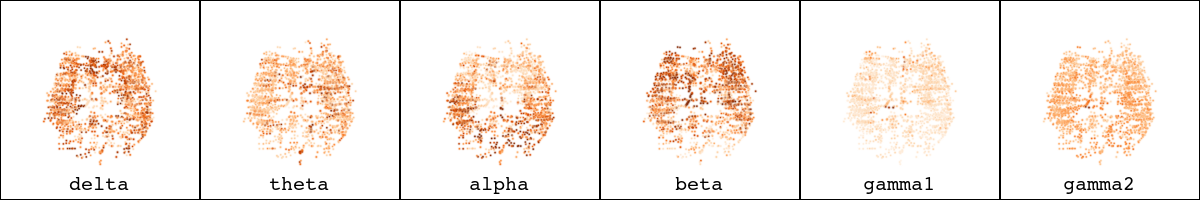

In [17]:
import copy
import pyvista as pv

pl = pv.Plotter(shape=(1, 6), window_size = (1200, 200))

for fi, fband in enumerate(bandpowers.columns):
    pl.subplot(0,fi)

    tmp = copy.copy(eeg)
    pl.add_points(tmp, scalars = fband, style = 'points_gaussian', cmap = 'Oranges', show_scalar_bar=False)
    pl.add_text(fband, font = 'courier', position = 'lower_edge', font_size = 9)
    pl.camera_position = 'xy'
pl.show(jupyter_backend='static')

# Only keep the left hemisphere

In [28]:
left_channel_ind = np.where( eeg.points[:,0] < 0)[0]

In [29]:
left_eeg = pv.PolyData(eeg.points[left_channel_ind,:])

In [33]:
for fband in bandpowers_z.columns:
    left_eeg[fband] = bandpowers_z[fband][left_channel_ind]

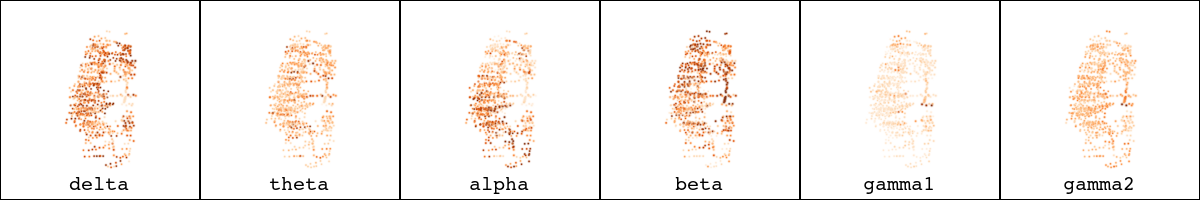

In [39]:
import copy
import pyvista as pv

pl = pv.Plotter(shape=(1, 6), window_size = (1200, 200))

for fi, fband in enumerate(bandpowers.columns):
    pl.subplot(0,fi)

    tmp = copy.copy(left_eeg)
    pl.add_points(tmp, scalars = fband, style = 'points_gaussian', cmap = 'Oranges', show_scalar_bar=False)
    pl.add_text(fband, font = 'courier', position = 'lower_edge', font_size = 9)
    pl.camera_position = 'xy'
pl.show(jupyter_backend='static')

## Remove outliers

In [47]:
from config import *

In [ ]:
fbands = bandpowers.columns

outlier_inds = dict.fromkeys(fbands)

pl = pv.Plotter(shape=(1,6), window_size = (1200,200))

for fi, fband in enumerate( fbands ):

    distr = zscore( left_eeg[fband] )
    
    retain_ind = np.where(abs(distr) < 3)[0]
    remove_ind = np.where(abs(distr) >= 3)[0]

    outlier_inds[fband] = remove_ind

    new_no_outlier = pv.PolyData(left_eeg.points[retain_ind,:])
    new_no_outlier[fband + '_zscored_no_outlier'] = left_eeg[fband][retain_ind]

    import joblib
    import nibabel as nb
    from nibabel.affines import apply_affine
    import numpy as np
    import numpy.linalg as npl
    import os
    from scipy.ndimage import map_coordinates
    
    reregistered_pet_dir = '/home/yzhou/projects/out_2009c/'
    
    fnames = os.listdir(reregistered_pet_dir)
    
    for fname in fnames:
        PET = nb.load(reregistered_pet_dir + fname)
    
        sourcetag = fname.split('_')[0].split('-')[1]
        desctag = fname.split('_')[1].split('-')[1]
    
        maptag = f'pet_{sourcetag}_{desctag}'
    
        points = new_no_outlier.points
        img_data = PET.get_fdata()
        inverse_aff = npl.inv(PET.affine)
        ijk_points = apply_affine(inverse_aff, points)
    
        vals = np.zeros(new_no_outlier.n_points)
        for pi in range(points.shape[0]):
            
            vox_value = map_coordinates(img_data, ijk_points[pi,:].reshape(-1,1), order=1)
            print(vox_value)
            vals[pi] = vox_value[0]
            
        new_no_outlier[maptag] = vals

    pl.subplot(0, fi)
    pl.add_points(new_no_outlier.rotate_z(180), scalars = fband + '_zscored_no_outlier', \
                  style = 'points_gaussian', cmap = 'Oranges', show_scalar_bar=False)
    pl.add_text(fband, font = 'courier', position = 'lower_edge', font_size = 9)
    pl.camera_position = 'yz'

    joblib.dump(new_no_outlier, projdir + f'/data/icbm09c_left-volume_ieeg-{fband}-pet.pkl')
    
pl.show(jupyter_backend = 'static')

In [50]:
new_no_outlier.array_names

['gamma2_zscored_no_outlier',
 'pet_bedard2019_feobv',
 'pet_aghourian2017_feobv',
 'pet_naganawa2020_lsn3172176',
 'pet_hillmer2016_flubatine',
 'pet_vijay2018_ly2795050',
 'pet_finnema2016_ucbj',
 'pet_dukart2018_fpcit',
 'pet_savli2012_p943',
 'pet_hesse2017_methylreboxetine',
 'pet_satterthwaite2014_meancbf',
 'pet_gallezot2017_gsk189254',
 'pet_laurikainen2018_fmpepd2',
 'pet_smith2017_flb457',
 'pet_dubois2015_abp688',
 'pet_sasaki2012_fepe2i',
 'pet_fazio2016_madam',
 'pet_tuominen_feobv',
 'pet_gallezot2010_p943',
 'pet_kantonen2020_carfentanil',
 'pet_savli2012_dasb',
 'pet_radnakrishnan2018_gsk215083',
 'pet_ding2010_mrb',
 'pet_normandin2015_omar',
 'pet_rosaneto_abp688',
 'pet_alarkurtti2015_raclopride',
 'pet_smart2019_abp688',
 'pet_jaworska2020_fallypride',
 'pet_savli2012_altanserin',
 'pet_dukart2018_flumazenil',
 'pet_turtonen2020_carfentanil',
 'pet_savli2012_way100635',
 'pet_kaller2017_sch23390']

## inspect interpolated maps

                           idw         knn         rbf         swr  \
pearson               0.352090    0.386355    0.375326    0.267505   
spearman              0.347109    0.367838    0.358052    0.119516   
ssim                  0.994081    0.993209    0.992895    0.994750   
r2                 -207.333054 -222.148575 -234.280151 -178.290466   
rmse                  0.582387    0.602739    0.618907    0.540270   
kolmogorov_smirnov    0.685746    0.665740    0.670742    0.994165   
jensen_shannon        0.078759    0.079016    0.078945    0.030530   
run_time              0.096724    0.019102    0.585955   12.079655   

                         krige    regkrige  
pearson               0.442090    0.365059  
spearman              0.419145    0.329913  
ssim                  0.994793    0.992887  
r2                 -157.107544 -240.869370  
rmse                  0.507351    0.627513  
kolmogorov_smirnov    0.731870    0.663240  
jensen_shannon        0.058521    0.078297  
run_time 

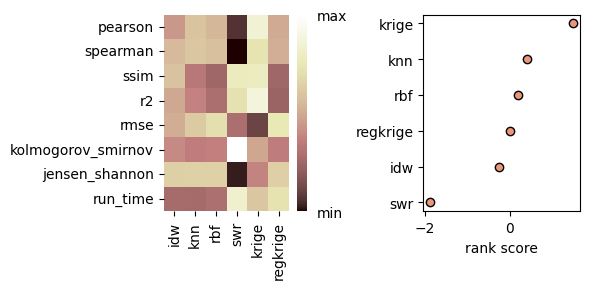

(3599,)
3599


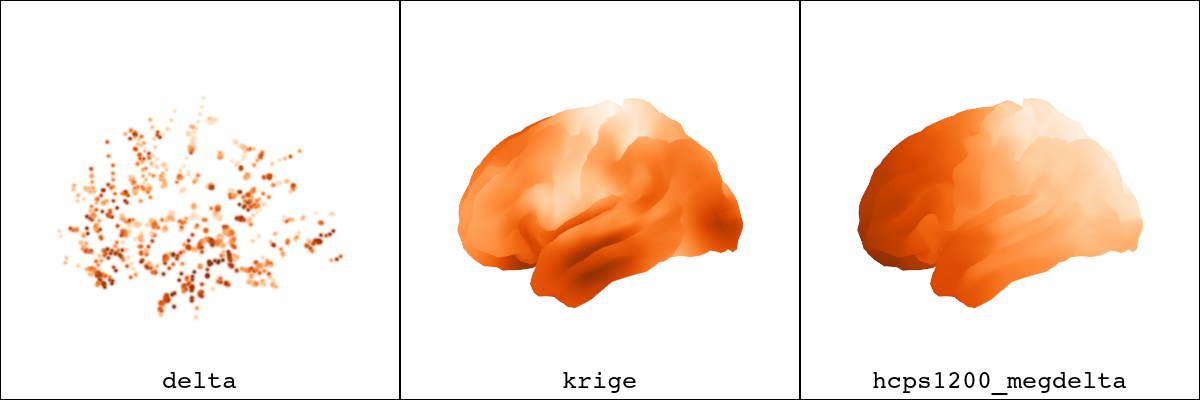

                           idw         knn         rbf         swr  \
pearson               0.137450    0.137902    0.124794   -0.170035   
spearman              0.118586    0.127904    0.114442   -0.290838   
ssim                  0.996003    0.996435    0.996376    0.997329   
r2                 -314.489685 -262.012268 -272.573761 -159.495636   
rmse                  0.487626    0.445227    0.454079    0.347797   
kolmogorov_smirnov    0.812448    0.814949    0.805779    0.995276   
jensen_shannon        0.101523    0.097589    0.105933    0.114371   
run_time              0.080050    0.015431    0.322991   13.882638   

                         krige    regkrige  
pearson               0.130188    0.206176  
spearman              0.128782    0.191186  
ssim                  0.997372    0.996415  
r2                 -173.785019 -243.218292  
rmse                  0.362949    0.429025  
kolmogorov_smirnov    0.928869    0.860239  
jensen_shannon        0.122866    0.093560  
run_time 

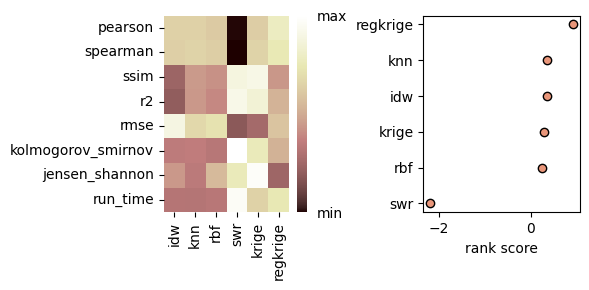

(3599,)
3599


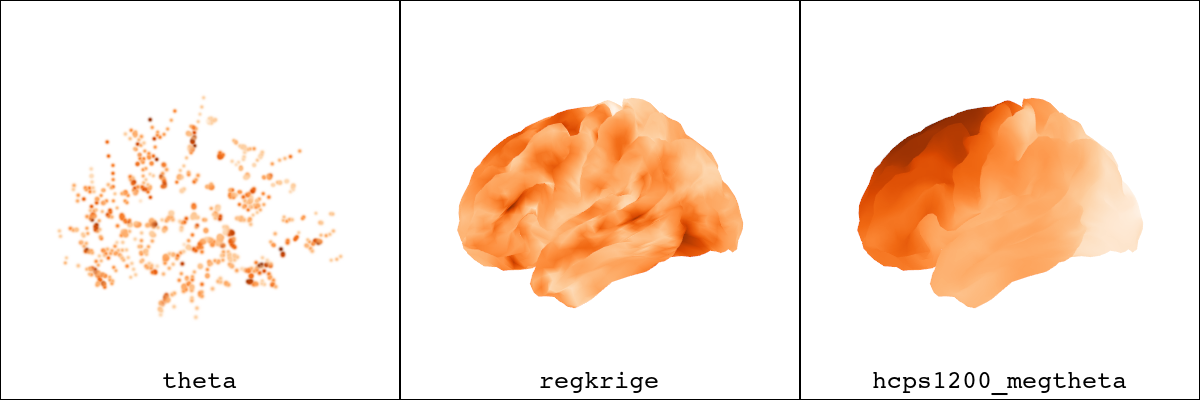

                          idw        knn        rbf        swr      krige  \
pearson              0.705733   0.736046   0.726909   0.562727   0.748140   
spearman             0.728051   0.739384   0.729544   0.612353   0.756658   
ssim                 0.994552   0.994255   0.994430   0.997251   0.991828   
r2                 -67.532257 -65.629135 -64.191711 -33.884750 -95.292496   
rmse                 0.559105   0.551287   0.545308   0.398900   0.662738   
kolmogorov_smirnov   0.558488   0.569325   0.569603   0.598777   0.557377   
jensen_shannon       0.076766   0.070302   0.068143   0.046808   0.082963   
run_time             0.094979   0.023092   0.423504  12.906341   7.536631   

                     regkrige  
pearson              0.694971  
spearman             0.701806  
ssim                 0.992325  
r2                 -93.880981  
rmse                 0.657863  
kolmogorov_smirnov   0.543484  
jensen_shannon       0.087289  
run_time             9.801930  


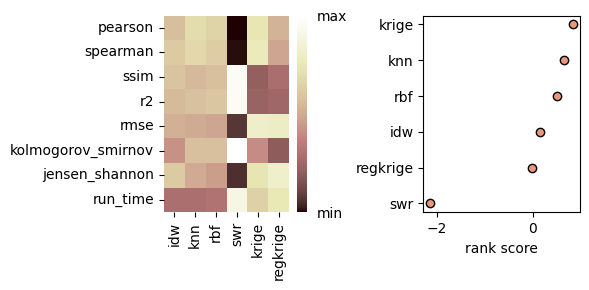

(3599,)
3599


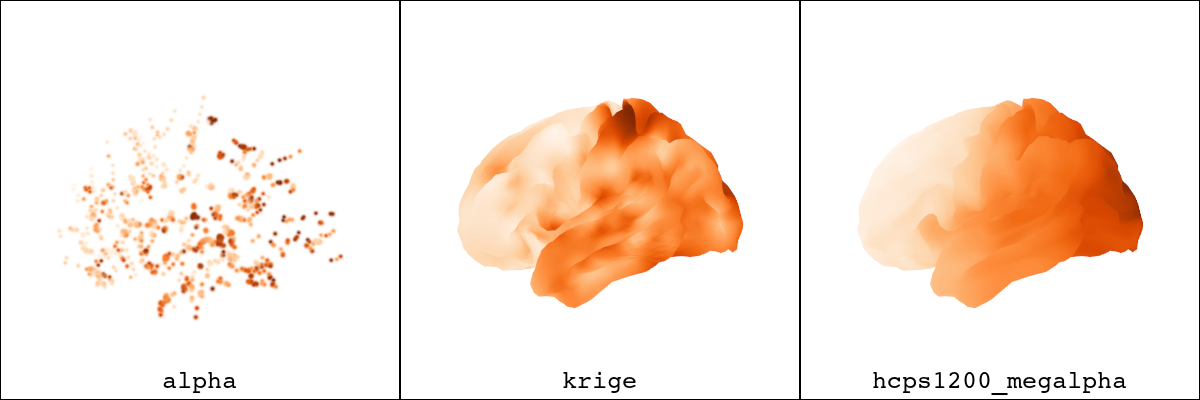

                            idw          knn          rbf          swr  \
pearson                0.563037     0.619331     0.648239     0.330731   
spearman               0.623888     0.661387     0.688706     0.302010   
ssim                   0.987131     0.986061     0.986274     0.989834   
r2                 -3047.364014 -3240.435791 -3175.423340 -2382.383057   
rmse                   0.798918     0.823829     0.815526     0.706424   
kolmogorov_smirnov     0.850236     0.793832     0.789108     0.933870   
jensen_shannon         0.069365     0.074981     0.074878     0.029208   
run_time               0.085315     0.025226     0.697489    11.840733   

                          krige     regkrige  
pearson                0.414626     0.457800  
spearman               0.484780     0.521219  
ssim                   0.985093     0.984221  
r2                 -3603.719727 -3920.384033  
rmse                   0.868769     0.906125  
kolmogorov_smirnov     0.809391     0.816894  
jens

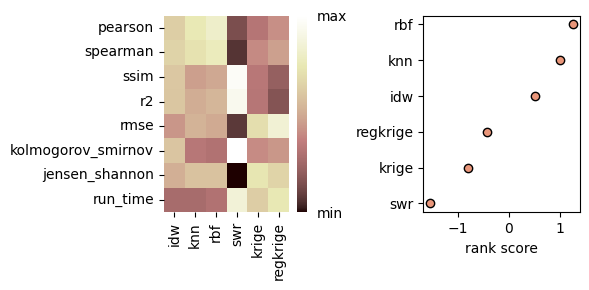

(3599,)
3599


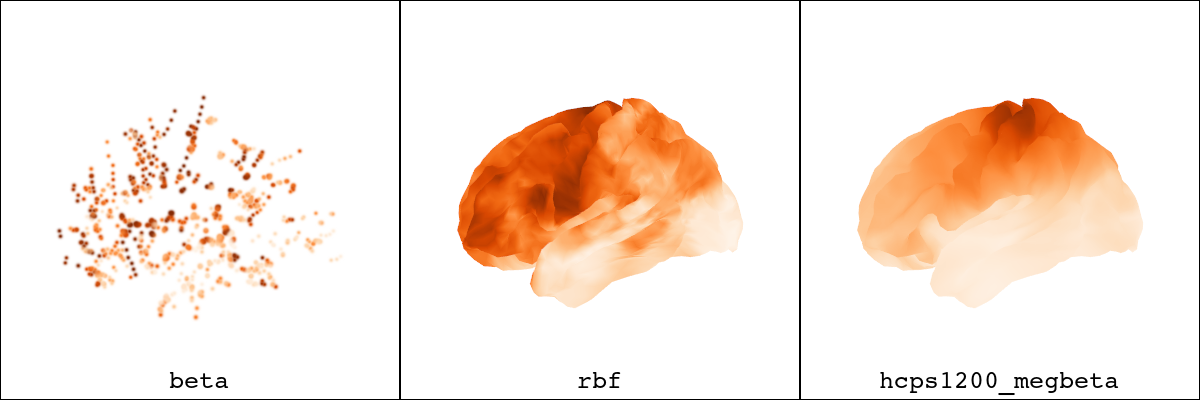

                             idw           knn           rbf           swr  \
pearson                 0.331009      0.386190      0.383468      0.077666   
spearman                0.355041      0.359318      0.359871      0.244939   
ssim                    0.986144      0.986260      0.986199      0.985781   
r2                 -32519.648438 -32218.556641 -32366.865234 -33080.675781   
rmse                    0.793538      0.789856      0.791672      0.800354   
kolmogorov_smirnov      0.999444      1.000000      1.000000      1.000000   
jensen_shannon          0.019827      0.023998      0.023712      0.009038   
run_time                0.078245      0.022172      0.619259     11.509115   

                           krige      regkrige  
pearson                 0.476457      0.373708  
spearman                0.417756      0.313373  
ssim                    0.986692      0.986002  
r2                 -31242.160156 -33020.628906  
rmse                    0.777796      0.799627  
kol

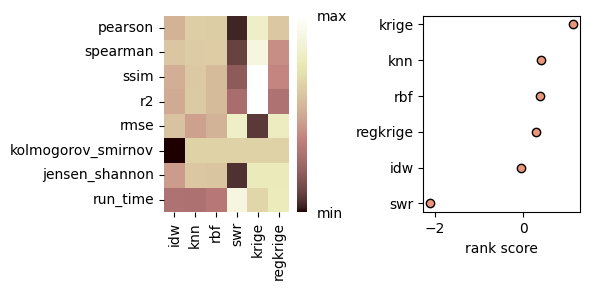

(3599,)
3599


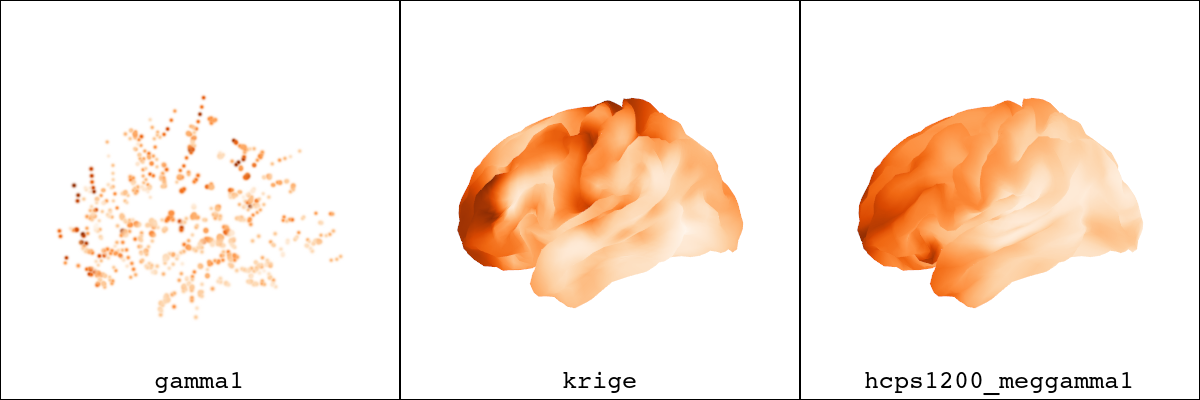

                              idw            knn            rbf  \
pearson                 -0.009865       0.011089       0.005927   
spearman                -0.008138       0.017890       0.018222   
ssim                     0.966893       0.966809       0.966780   
r2                 -114540.921875 -114634.210938 -114680.789062   
rmse                     1.243692       1.244199       1.244451   
kolmogorov_smirnov       1.000000       1.000000       1.000000   
jensen_shannon           0.022759       0.022529       0.022200   
run_time                 0.129957       0.012168       0.319761   

                              swr          krige       regkrige  
pearson                 -0.312673      -0.213567      -0.107723  
spearman                -0.328889      -0.219461      -0.097210  
ssim                     0.967112       0.967472       0.966354  
r2                 -111714.289062 -110481.906250 -114929.718750  
rmse                     1.228251       1.221457       1.245801  


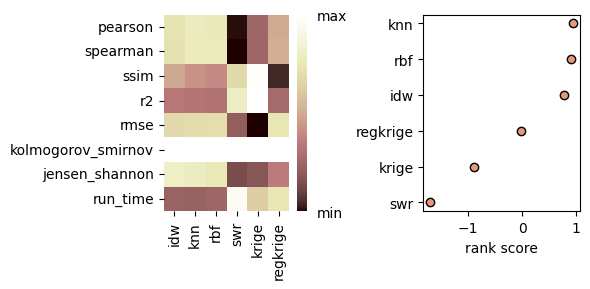

(3599,)
3599


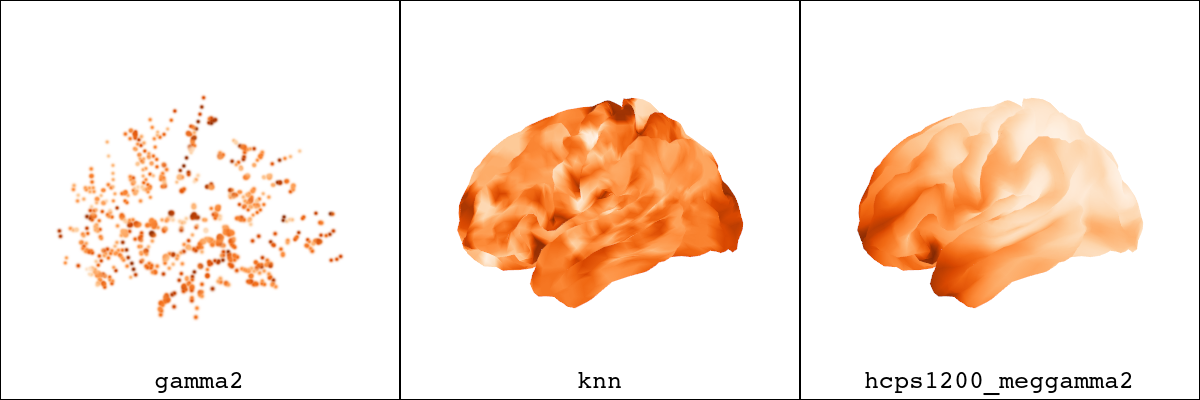

In [58]:
import joblib
from scipy.stats import zscore


compare = joblib.load(projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')

for fband in ['delta', 'theta', 'alpha', 'beta', 'gamma1', 'gamma2']:

    res = joblib.load(projdir + f'/results/ieeg-{fband}-pet/all/fsLR-4k_{fband}_zscored_no_outlier_left-volume_ieeg-{fband}-pet_samp-all_pct-100_0_all_info.pkl')
    electrodes = joblib.load(projdir + f'/data/icbm09c_left-volume_ieeg-{fband}-pet.pkl')
    # scale evenly for visualization
    perf = res['performance'][0].dropna(axis=1)
    perf = zscore( perf, axis = 1 )
    print(res['performance'][0])
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    left_ind = np.where(electrodes.points[:,0] < 0)[0]
    left_hemi_electrodes = electrodes.points[ left_ind,: ]
    left_points = pv.PolyData(left_hemi_electrodes)
    
    fig, axs = plt.subplots(1,2, figsize = (6,3))
    
    axs[0] = sns.heatmap( perf, cmap = 'pink', ax=axs[0])
    cbar = axs[0].collections[0].colorbar
    cbar.ax.tick_params(left=False, right=False, labelleft=False)
    vmin = np.nanmin(perf)
    vmax = np.nanmax(perf)
    # Set ticks at min and max
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["min", "max"])
    
    
    ranks = perf.loc['pearson'].sort_values()
    axs[1].scatter(ranks, ranks.index, color = 'darksalmon', edgecolor = 'k')
    axs[1].set_xlabel('rank score')
    
    plt.tight_layout()
    plt.show()

    import pyvista as pv

    mesh_aes = {"show_scalar_bar": False,\
                "smooth_shading": True,\
                "specular": 0, "diffuse":0, "ambient":1}
    
    pl = pv.Plotter(shape = (1,3), window_size = (1200,400))

    approach = ranks.index[-1]
    compare_maptag = f'hcps1200_meg{fband}'

    pl.subplot(0,0)
    pl.add_points(left_points.rotate_z(180), scalars = electrodes[fband + '_zscored_no_outlier'][left_ind], \
                  style = 'points_gaussian', cmap = 'Oranges', show_scalar_bar = False)
    pl.add_text(fband, position = 'lower_edge', font = 'courier', font_size = 10)
    pl.camera_position = 'yz'
    
    pl.subplot(0,1)
    print(res['interpolated'][approach].shape)
    print(compare.n_points)
    pl.add_mesh(compare.rotate_z(180), scalars = res['interpolated'][approach], cmap = 'Oranges', **mesh_aes)
    pl.add_text(approach, position = 'lower_edge', font = 'courier', font_size = 10)
    pl.camera_position = 'yz'
    
    pl.subplot(0,2)
    pl.add_mesh(compare.rotate_z(180), scalars = f'hcps1200_meg{fband}', cmap = 'Oranges', **mesh_aes)
    pl.add_text(compare_maptag, position = 'lower_edge', font = 'courier', font_size = 10)
    pl.camera_position = 'yz'
    pl.show(jupyter_backend = 'static')
    

In [118]:
res['interpolant_labels']

['idw5', 'knn6', 'rbf5gaussian']

In [122]:
res['performance'][0]

,idw,knn,rbf,swr,krige,regkrige
pearson,0.056522,0.040231,0.028239,-0.025906,0.043547,0.073153
spearman,0.019377,0.005096,-0.002345,-0.094823,-0.028340,0.029628
ssim,0.996813,0.996863,0.996839,0.999347,0.998423,0.996935
r2,-273.863800,-256.045746,-261.740692,-39.241882,-122.086624,-232.091461
rmse,0.455148,0.440148,0.444997,0.174154,0.304579,0.419138
kolmogorov_smirnov,0.766046,0.749097,0.745485,0.986663,0.820784,0.770214
jensen_shannon,0.125637,0.111543,0.114966,0.052947,0.132552,0.107231
run_time,0.192848,0.025123,0.329737,30.616487,44.816264,141.924401


In [145]:
# scale evenly for visualization
from scipy.stats import zscore

perf = zscore( res['performance'][0], axis = 1 )

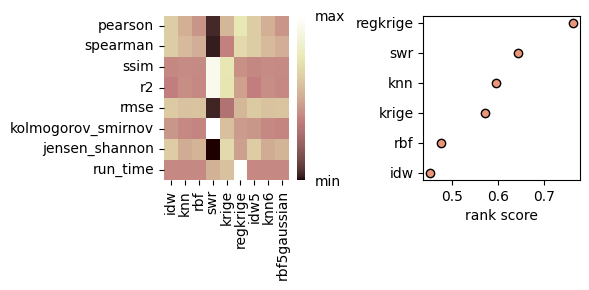

In [146]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



fig, axs = plt.subplots(1,2, figsize = (6,3))

axs[0] = sns.heatmap( perf, cmap = 'pink', ax=axs[0])
cbar = axs[0].collections[0].colorbar
cbar.ax.tick_params(left=False, right=False, labelleft=False)
vmin = np.nanmin(perf)
vmax = np.nanmax(perf)
# Set ticks at min and max
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(["min", "max"])


ranks = res['performance'][1].sort_values()
axs[1].scatter(ranks, ranks.index, color = 'darksalmon', edgecolor = 'k')
axs[1].set_xlabel('rank score')

plt.tight_layout()
plt.show()

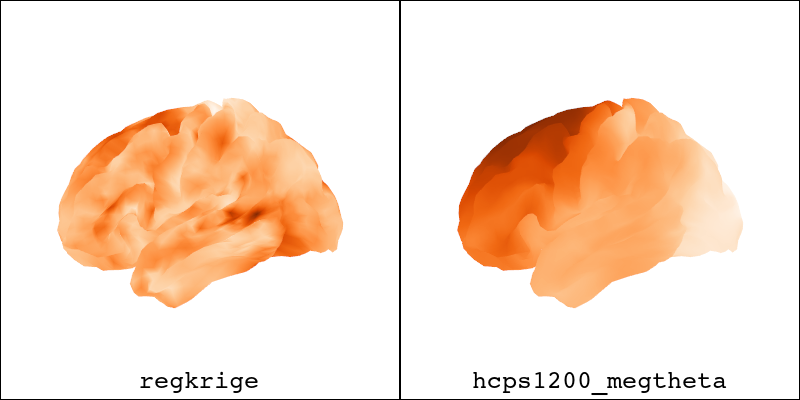

In [123]:
import pyvista as pv

mesh_aes = {"show_scalar_bar": False,\
            "smooth_shading": True,\
            "specular": 0, "diffuse":0, "ambient":1}

pl = pv.Plotter(shape = (1,2), window_size = (800,400))

approach = res['performance'][0].loc['pearson'].sort_values().index[-1]
compare_maptag = f'hcps1200_meg{fband}'

pl.subplot(0,0)
pl.add_mesh(compare.rotate_z(180), scalars = res['interpolated'][approach], cmap = 'Oranges', **mesh_aes)
pl.add_text(approach, position = 'lower_edge', font = 'courier', font_size = 10)
pl.camera_position = 'yz'

pl.subplot(0,1)
pl.add_mesh(compare.rotate_z(180), scalars = f'hcps1200_meg{fband}', cmap = 'Oranges', **mesh_aes)
pl.add_text(compare_maptag, position = 'lower_edge', font = 'courier', font_size = 10)
pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')